# Exploratory Data Analysis (EDA)







Exploratory Data Analysis (EDA) is a crucial step in the data analysis process that involves **examining datasets to summarize their main characteristics**, often using visual methods.

It helps in:
 - understanding the data,
    - what is the information our data carry?
    - what characteristics will be useful for their analysis?
    - what are the limitations?
 - uncovering patterns,
 - check data consistency,
 - spotting anomalies,
 - and testing hypotheses.

The major steps in a comprehensive EDA include:

1. **Understand the Dataset:** Examine the dataset's structure, content, and context. Identify data types, review variable definitions, and assess data quality. This provides a clear understanding of the information contained in the dataset and its potential value for analysis.

1. **Data Cleaning:** Identify and handle missing or inconsistent data. This may involve imputing missing values, correcting errors, or removing irrelevant data to ensure the dataset is accurate and reliable.

1. **Descriptive Statistics:** Generate summary statistics such as mean, median, standard deviation, and range for numerical variables. For categorical variables, calculate frequencies and mode. This step provides insights into the central tendency and dispersion of the data.

1. **Data Visualization:** Create visual representations like histograms, box plots, scatter plots, and bar charts to identify patterns, trends, and potential outliers. Visualization aids in understanding relationships between variables and detecting anomalies.

1. **Identify Outliers and Anomalies:** Detect data points that deviate significantly from the rest of the dataset. Investigate these anomalies to determine if they result from data entry errors, measurement errors, or genuine variability.

1. **Assess Relationships Between Variables:** Analyze correlations and interactions between variables using correlation matrices or pair plots. This helps in understanding dependencies and potential predictors for modeling.

1. **Dimensionality Reduction:** If dealing with high-dimensional data, apply techniques like Principal Component Analysis (PCA) to reduce the number of variables while retaining most of the information. This simplifies analysis and visualization.

1. **Formulate Hypotheses:** Based on the insights gained, develop hypotheses about the data. These hypotheses can guide further analysis and inform decision-making processes.

1. **Document Findings:** Summarize the insights, patterns, and anomalies discovered during EDA. Proper documentation ensures that the findings can be referenced in future analyses and supports transparency.


Let's see some examples!

## World Population dataset

In this tutorial we are going to explore a dataset containing the trend of countries' populatios from 1970 to 2022, with additional attributes like

- area and density,
- continent and capital,
- growth rate and percentage over the world population.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"https://github.com/AlexTheAnalyst/PandasYouTubeSeries/raw/refs/heads/main/world_population.csv")
df

,Rank,CCA3,Country,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,41128771.0,38972230.0,33753499.0,28189672.0,19542982.0,10694796.0,12486631.0,10752971.0,652230.0,63.0587,1.0257,0.52
1,138,ALB,Albania,Tirana,Europe,2842321.0,2866849.0,2882481.0,2913399.0,3182021.0,3295066.0,2941651.0,2324731.0,28748.0,98.8702,0.9957,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225.0,43451666.0,39543154.0,35856344.0,30774621.0,25518074.0,18739378.0,13795915.0,2381741.0,18.8531,1.0164,0.56
3,213,ASM,American Samoa,Pago Pago,Oceania,44273.0,46189.0,51368.0,54849.0,58230.0,47818.0,32886.0,27075.0,199.0,222.4774,0.9831,0.00
4,203,AND,Andorra,Andorra la Vella,Europe,79824.0,77700.0,71746.0,71519.0,66097.0,53569.0,35611.0,19860.0,468.0,170.5641,1.0100,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229,226,WLF,Wallis and Futuna,Mata-Utu,Oceania,11572.0,11655.0,12182.0,13142.0,14723.0,13454.0,11315.0,9377.0,142.0,81.4930,0.9953,0.00
230,172,ESH,Western Sahara,El Aaiún,Africa,575986.0,556048.0,491824.0,413296.0,270375.0,178529.0,116775.0,76371.0,266000.0,2.1654,1.0184,0.01
231,46,YEM,Yemen,Sanaa,Asia,33696614.0,32284046.0,28516545.0,24743946.0,18628700.0,13375121.0,9204938.0,6843607.0,527968.0,63.8232,1.0217,0.42
232,63,ZMB,Zambia,Lusaka,Africa,20017675.0,18927715.0,NaN,13792086.0,9891136.0,7686401.0,5720438.0,4281671.0,752612.0,26.5976,1.0280,0.25


### First look at the data

First step is to just inspect what is the content of our data.

To do this it can be useful to adjust numbers formatting and get high-level info about our features.

In [6]:
# adjust data formatting for float variables
pd.set_option('display.float_format', lambda x: f'{x:.2f}') # {x:.2e}
df.head()

,Rank,CCA3,Country,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,41128771.00,38972230.00,33753499.00,28189672.00,19542982.00,10694796.00,12486631.00,10752971.00,652230.00,63.06,1.03,0.52
1,138,ALB,Albania,Tirana,Europe,2842321.00,2866849.00,2882481.00,2913399.00,3182021.00,3295066.00,2941651.00,2324731.00,28748.00,98.87,1.00,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225.00,43451666.00,39543154.00,35856344.00,30774621.00,25518074.00,18739378.00,13795915.00,2381741.00,18.85,1.02,0.56
3,213,ASM,American Samoa,Pago Pago,Oceania,44273.00,46189.00,51368.00,54849.00,58230.00,47818.00,32886.00,27075.00,199.00,222.48,0.98,0.00
4,203,AND,Andorra,Andorra la Vella,Europe,79824.00,77700.00,71746.00,71519.00,66097.00,53569.00,35611.00,19860.00,468.00,170.56,1.01,0.00


In [7]:
# note that formatting just changes the appearence, not the value
df.loc[0, "2022 Population"]

np.float64(41128771.0)

In [8]:
# check non-null count and types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Rank                         234 non-null    int64  
 1   CCA3                         234 non-null    object 
 2   Country                      234 non-null    object 
 3   Capital                      234 non-null    object 
 4   Continent                    234 non-null    object 
 5   2022 Population              230 non-null    float64
 6   2020 Population              233 non-null    float64
 7   2015 Population              230 non-null    float64
 8   2010 Population              227 non-null    float64
 9   2000 Population              227 non-null    float64
 10  1990 Population              229 non-null    float64
 11  1980 Population              229 non-null    float64
 12  1970 Population              230 non-null    float64
 13  Area (km²)          

From this we can already spot the types of the features and non-null values.

Also we get an indication of the memory occupied by our dataframe.

In [9]:
null_2020_population_mask = df["2020 Population"].isnull()
df[null_2020_population_mask]

,Rank,CCA3,Country,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
13,91,AZE,Azerbaijan,Baku,Asia,10358074.00,NaN,9863480.00,9237202.00,8190337.00,7427836.00,6383060.00,5425317.00,86600.00,119.61,1.00,0.13


> What can we say about our data???
 - are there any limitations?

For example, we do not have more recent data --> we only have partial info if we are interested in latest updates.

## Univariate distributions

Once we have a general understanding of our data content, the next step is to inspect the distributions of features.

In [13]:
# get insights on variables quantiles/distributions
# NOTE: only works for numerical features
df.describe(percentiles=[.10, 0.25, 0.5, 0.75, .9])

,Rank,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
count,234.00,230.00,233.00,230.00,227.00,227.00,229.00,229.00,230.00,232.00,230.00,232.00,234.00
mean,117.50,34632250.88,33600710.95,32066004.16,30270164.48,26840495.26,19330463.93,16282884.78,15866499.13,581663.75,456.81,1.01,0.43
std,67.69,137889172.44,135873196.61,131507146.34,126074183.54,113352454.57,81309624.96,69345465.54,68355859.75,1769133.06,2083.74,0.01,1.71
min,1.00,510.00,520.00,564.00,596.00,651.00,700.00,733.00,752.00,1.00,0.03,0.91,0.00
10%,24.30,49361.60,48031.00,49350.60,51413.60,50798.40,44964.80,31337.20,24239.90,243.80,15.53,1.00,0.00
25%,59.25,419738.50,406471.00,394295.00,382726.50,329470.00,261928.00,223752.00,145880.50,2567.25,36.60,1.00,0.01
50%,117.50,5762857.00,5456681.00,5244415.00,4889741.00,4491202.00,3785847.00,3135123.00,2511718.00,77141.00,95.35,1.01,0.07
75%,175.75,22653719.00,21522626.00,19730853.75,16825852.50,15625467.00,11882762.00,9817257.00,8817329.00,414643.25,236.88,1.02,0.28
90%,210.70,60367159.30,59360848.60,56312144.20,54999932.60,48721692.20,40903650.20,35915476.40,28853028.80,1238276.50,523.29,1.03,0.75
max,234.00,1425887337.00,1424929781.00,1393715448.00,1348191368.00,1264099069.00,1153704252.00,982372466.00,822534450.00,17098242.00,23172.27,1.07,17.88


In [11]:
# easier visualization (?)
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Rank,234.00,117.50,67.69,1.00,59.25,117.50,175.75,234.00
2022 Population,230.00,34632250.88,137889172.44,510.00,419738.50,5762857.00,22653719.00,1425887337.00
2020 Population,233.00,33600710.95,135873196.61,520.00,406471.00,5456681.00,21522626.00,1424929781.00
2015 Population,230.00,32066004.16,131507146.34,564.00,394295.00,5244415.00,19730853.75,1393715448.00
2010 Population,227.00,30270164.48,126074183.54,596.00,382726.50,4889741.00,16825852.50,1348191368.00
2000 Population,227.00,26840495.26,113352454.57,651.00,329470.00,4491202.00,15625467.00,1264099069.00
1990 Population,229.00,19330463.93,81309624.96,700.00,261928.00,3785847.00,11882762.00,1153704252.00
1980 Population,229.00,16282884.78,69345465.54,733.00,223752.00,3135123.00,9817257.00,982372466.00
1970 Population,230.00,15866499.13,68355859.75,752.00,145880.50,2511718.00,8817329.00,822534450.00
Area (km²),232.00,581663.75,1769133.06,1.00,2567.25,77141.00,414643.25,17098242.00


An important step in the initial stage is to check if there are **missing values**.

In [14]:
# check missing values
df.isnull().sum()

,0
Rank,0
CCA3,0
Country,0
Capital,0
Continent,0
2022 Population,4
2020 Population,1
2015 Population,4
2010 Population,7
2000 Population,7


**Note:** sometimes this is not enough, and spotting missings is more tricky.

For example, some data have missing values encoded as *weird* values. This means they use values that are out of scale with respect to normal feature values, e.g.:

 - Area: -1
 - Growth Rate: 9999

 > Remember to always:
  - check data documentation
  - carefully inspect data
  - ...if you are sharing data: please provide comprehensive documentation to maximise re-use!

In [ ]:
# # is this a real problem? In case we can filter out cols with too many missings (above some toleracnce threshold)
# missing_tol = 0.3
# non_missing_check = df.count() / df.shape[1] > (1- missing_tol)
# non_missing_cols = (non_missing_check == True).index

# df[non_missing_cols]

Another aspect you may want to check are **unique values**. This is helpful to check data consistency and uncover unexpected patterns.

> For example:
 - feature with only 1 unique value: all entries are equal, so we cannot discriminate based on that feature
>
>--> useless even if potentially relevant

In [15]:
# check unique values: help undrstanding how much info is contained in each feature
df.nunique()

,0
Rank,234
CCA3,234
Country,234
Capital,234
Continent,6
2022 Population,230
2020 Population,233
2015 Population,230
2010 Population,227
2000 Population,227


> **Are these values as you expected?**
 - Continent
 - Capital/Country
 - Population values?
 - World Population Percentage?

In [ ]:
# df.tail()

### Data Visualization (data viz)

**Can we explore the distributions more easily?**

Looking at tables gives you a precise idea of the scale of features, their values, ...

...but sometimes it is not that easy to digest. In those cases, we can leverage data visualization techniques to gain more readable insights.

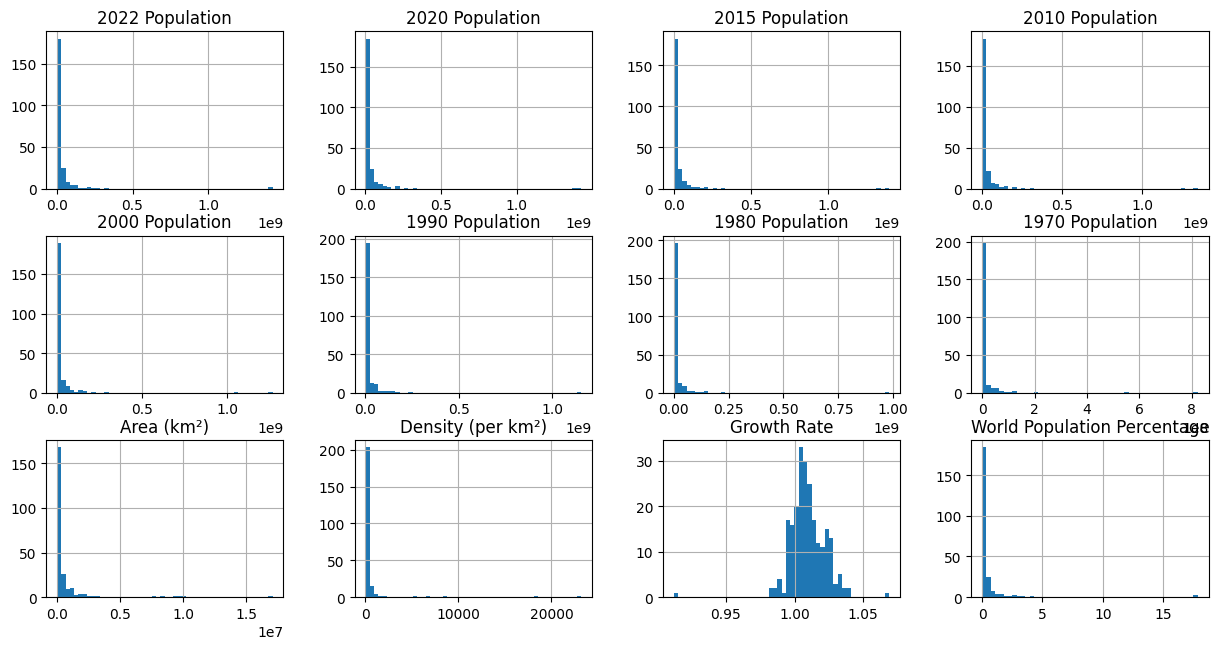

In [16]:
# exclude rank
df.columns
plot_df = df[df.columns[1:]]
axes = plot_df.hist(bins=50, layout=(4,4), figsize=(15,10))
plt.show()

In one picture we can spot several data characteristics and compare all features at once.

For example, most variables have a right-skewed distribution with the core shifted towards low values and longer right tails.

`Growth Rate` is instead more symmetric and centered around 1.


Another example:

<Axes: ylabel='Continent'>

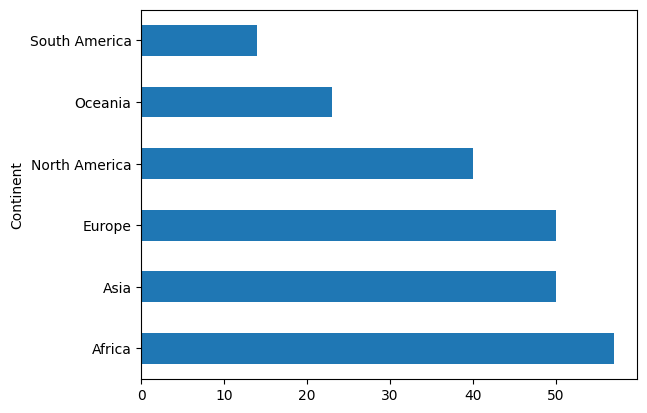

In [17]:
col = "Continent"
df.Continent.value_counts().plot.barh(col)

In [26]:
df[["Country", "Continent"]].query("Country == 'Jamaica'")

,Country,Continent
101,Jamaica,North America


The bar chart shows how many countries are labeled by each continent value.

For example we can see Africa is the continent with most countries, followed by Asia and Europe.

> Interestingly, South America is the continent with the fewest countries despite its large territorial extension!

## Exploring biggest countries by popolation

After we have a grasp of individual variables, we can start drilling down and explore more complex relationships.

Let's say we are interested in seeing what are countries with larger population.

> which feature do we consider for population numerosity?

In [28]:
df.sort_values(by="World Population Percentage", ascending=False).head(10)

,Rank,CCA3,Country,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
41,1,CHN,China,Beijing,Asia,1425887337.00,1424929781.00,1393715448.00,1348191368.00,1264099069.00,1153704252.00,982372466.00,822534450.00,9706961.00,146.89,1.00,17.88
92,2,IND,India,New Delhi,Asia,1417173173.00,1396387127.00,1322866505.00,1240613620.00,1059633675.00,NaN,NaN,557501301.00,3287590.00,431.07,1.01,17.77
221,3,USA,United States,"Washington, D.C.",North America,338289857.00,335942003.00,324607776.00,311182845.00,282398554.00,248083732.00,223140018.00,200328340.00,9372610.00,36.09,1.00,4.24
93,4,IDN,Indonesia,Jakarta,Asia,275501339.00,271857970.00,259091970.00,244016173.00,214072421.00,182159874.00,148177096.00,115228394.00,1904569.00,144.65,1.01,3.45
156,5,PAK,Pakistan,Islamabad,Asia,235824862.00,227196741.00,210969298.00,194454498.00,154369924.00,115414069.00,80624057.00,59290872.00,881912.00,267.40,1.02,2.96
149,6,NGA,Nigeria,Abuja,Africa,218541212.00,208327405.00,183995785.00,160952853.00,122851984.00,95214257.00,72951439.00,55569264.00,923768.00,236.58,1.02,2.74
27,7,BRA,Brazil,Brasilia,South America,215313498.00,213196304.00,205188205.00,196353492.00,175873720.00,150706446.00,122288383.00,96369875.00,8515767.00,25.28,1.00,2.70
16,8,BGD,Bangladesh,Dhaka,Asia,171186372.00,167420951.00,157830000.00,148391139.00,129193327.00,107147651.00,83929765.00,67541860.00,147570.00,1160.04,1.01,2.15
171,9,RUS,Russia,Moscow,Europe,144713314.00,145617329.00,144668389.00,143242599.00,146844839.00,148005704.00,138257420.00,130093010.00,17098242.00,8.46,1.00,1.81
131,10,MEX,Mexico,Mexico City,North America,127504125.00,125998302.00,120149897.00,112532401.00,97873442.00,81720428.00,67705186.00,50289306.00,1964375.00,64.91,1.01,1.60


What about smaller countries?

In [29]:
# df.sort_values(by="World Population Percentage", ascending=False).tail(10)
# equivalent to
df.sort_values(by="World Population Percentage", ascending=True).head(10)

,Rank,CCA3,Country,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
3,213,ASM,American Samoa,Pago Pago,Oceania,44273.00,46189.00,51368.00,54849.00,58230.00,47818.00,32886.00,27075.00,199.00,222.48,0.98,0.00
7,201,ATG,Antigua and Barbuda,Saint John’s,North America,93763.00,92664.00,89941.00,85695.00,75055.00,63328.00,64888.00,64516.00,442.00,212.13,1.01,0.00
6,224,AIA,Anguilla,The Valley,North America,15857.00,15585.00,14525.00,13172.00,11047.00,8316.00,6560.00,6283.00,91.00,174.25,1.01,0.00
4,203,AND,Andorra,Andorra la Vella,Europe,79824.00,77700.00,71746.00,71519.00,66097.00,53569.00,35611.00,19860.00,468.00,170.56,1.01,0.00
10,198,ABW,Aruba,Oranjestad,North America,106445.00,106585.00,104257.00,100341.00,89101.00,65712.00,62267.00,59106.00,180.00,591.36,1.00,0.00
28,221,VGB,British Virgin Islands,Road Town,North America,31305.00,30910.00,29366.00,27556.00,20104.00,15617.00,11109.00,9581.00,151.00,207.32,1.01,0.00
22,206,BMU,Bermuda,Hamilton,North America,64184.00,64031.00,63144.00,63447.00,61371.00,57470.00,53565.00,52019.00,54.00,1188.59,1.00,0.00
17,186,BRB,Barbados,Bridgetown,North America,281635.00,280693.00,278083.00,274711.00,264657.00,258868.00,253575.00,241397.00,430.00,654.97,1.00,0.00
48,189,CUW,Curacao,Willemstad,North America,191163.00,189288.00,169572.00,159380.00,141424.00,155446.00,156851.00,150385.00,444.00,430.55,1.00,0.00
53,204,DMA,Dominica,Roseau,North America,72737.00,71995.00,70007.00,68755.00,68346.00,69481.00,72978.00,68895.00,751.00,96.85,1.00,0.00


## Correlations

Now we explore a bit the relationships among pairs of features.

In [30]:
df.corr(numeric_only=True, method='pearson') # linear correlation

,Rank,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
Rank,1.00,-0.36,-0.36,-0.35,-0.35,-0.34,-0.33,-0.33,-0.34,-0.38,0.13,-0.22,-0.36
2022 Population,-0.36,1.00,1.00,1.00,1.00,0.99,0.99,0.99,0.97,0.45,-0.03,-0.02,1.00
2020 Population,-0.36,1.00,1.00,1.00,1.00,1.00,0.99,0.99,0.98,0.45,-0.03,-0.03,1.00
2015 Population,-0.35,1.00,1.00,1.00,1.00,1.00,0.99,0.99,0.98,0.46,-0.03,-0.03,1.00
2010 Population,-0.35,1.00,1.00,1.00,1.00,1.00,1.00,0.99,0.98,0.46,-0.03,-0.04,1.00
2000 Population,-0.34,0.99,1.00,1.00,1.00,1.00,1.00,1.00,0.99,0.47,-0.03,-0.05,0.99
1990 Population,-0.33,0.99,0.99,0.99,1.00,1.00,1.00,1.00,1.00,0.52,-0.03,-0.07,0.99
1980 Population,-0.33,0.99,0.99,0.99,0.99,1.00,1.00,1.00,1.00,0.53,-0.03,-0.08,0.99
1970 Population,-0.34,0.97,0.98,0.98,0.98,0.99,1.00,1.00,1.00,0.51,-0.03,-0.08,0.97
Area (km²),-0.38,0.45,0.45,0.46,0.46,0.47,0.52,0.53,0.51,1.00,-0.06,-0.01,0.45


Possible questions we may be interested in:
- What are the most correlated features?
- Is this expected?
- What do you expect for correlation between population and area?

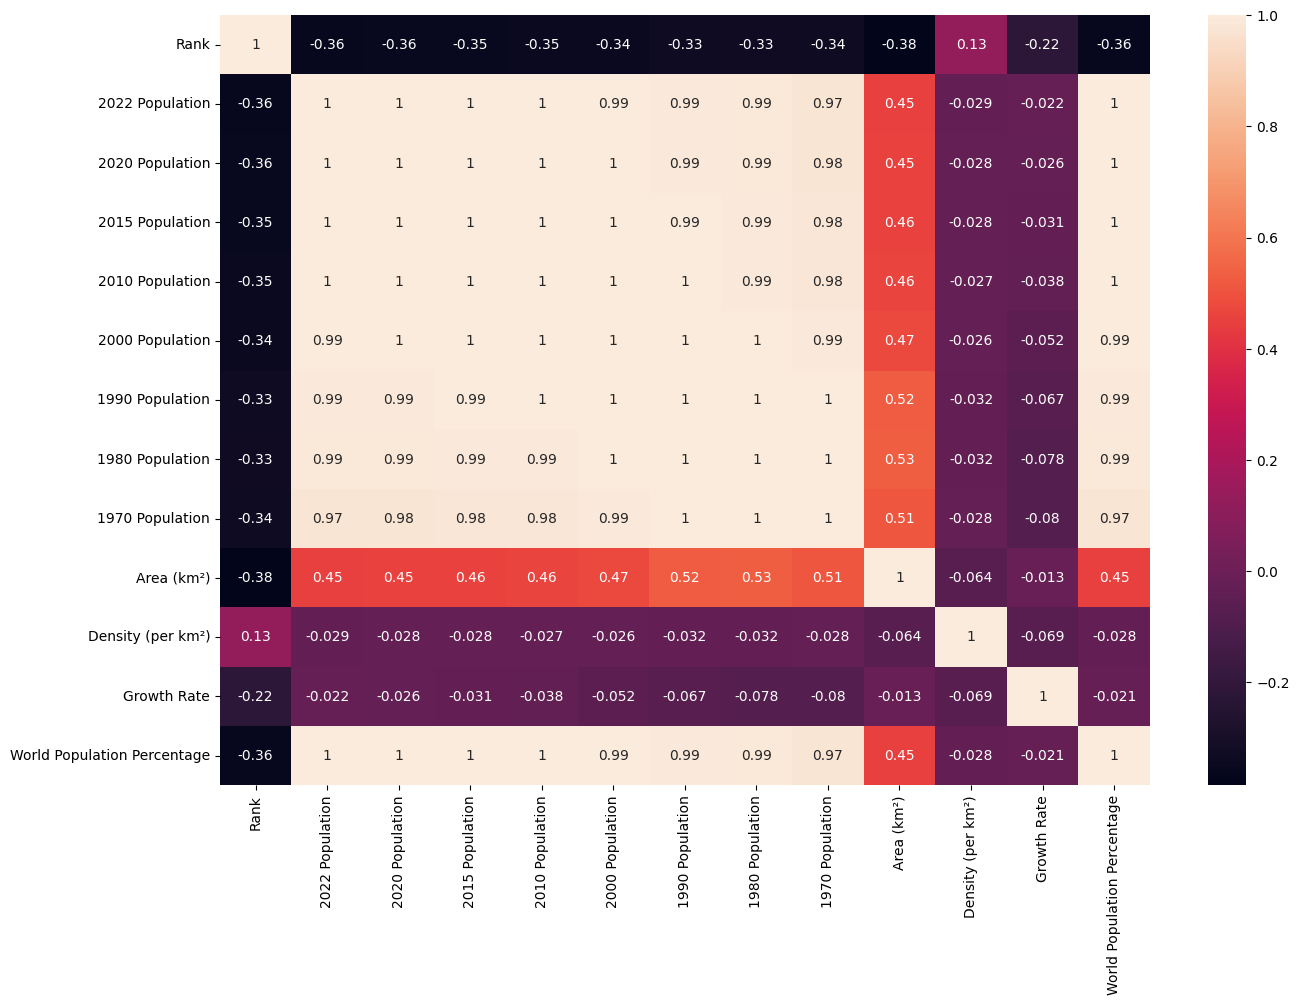

In [35]:
sns.heatmap(df.corr(numeric_only=True), annot = True)

plt.rcParams['figure.figsize'] = (15,10)

plt.show()

> **Note:** you can explore different kinds of correlation measures by changing the argument `method` in `.corr()`:
>
> - kendall : [Kendall Tau correlation coefficient](https://en.wikipedia.org/wiki/Kendall_rank_correlation_coefficient)
> - spearman : [Spearman rank correlation](https://en.wikipedia.org/wiki/Spearman%27s_rank_correlation_coefficient)

## Population by continent

In general, data exploration is **not a linear process!!!**. We typically jump back and forth from univariate to bivariate analysis depending on questions that arise along the way.

An example where we could be interested in the joint distribution of two features is if we want to inspect the *population* not in general, but by `Continent`.

This could be interesting to explore hypothesis like: "*are some continents growing faster than others?*"

In [ ]:
df.columns

Index(['Rank', 'CCA3', 'Country', 'Capital', 'Continent', '2022 Population',
       '2020 Population', '2015 Population', '2010 Population',
       '2000 Population', '1990 Population', '1980 Population',
       '1970 Population', 'Area (km²)', 'Density (per km²)', 'Growth Rate',
       'World Population Percentage'],
      dtype='object')

In [36]:
# let's check average population and median surface by continent
df.groupby('Continent').agg({
    '2022 Population': 'mean', 'Area (km²)': 'median', 'Density (per km²)': 'median'
    }).sort_values(by="2022 Population", ascending=False)
# grouped_df.select_dtypes(include='number').mean()#.sort_values(by="2022 Population",ascending=False)

,2022 Population,Area (km²),Density (per km²)
Continent,,,
Asia,96327387.31,164302.50,122.97
South America,31201186.29,406752.00,17.79
Africa,25455879.68,297715.00,58.71
Europe,15055371.82,53901.50,106.87
North America,15007403.40,1038.00,209.73
Oceania,2046386.32,702.00,78.25


Asia stands out as the continent with most populated countries, on average, in 2022.

In second place we have South America, despite having the lowest median density overall.

Oceania sits last both in terms of population and surface, in turn implying a greater density than South America nad Africa.

In [37]:
df[df['Continent'].str.contains('Oceania')]

,Rank,CCA3,Country,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
3,213,ASM,American Samoa,Pago Pago,Oceania,44273.00,46189.00,51368.00,54849.00,58230.00,47818.00,32886.00,27075.00,199.00,222.48,0.98,0.00
11,55,AUS,Australia,Canberra,Oceania,26177413.00,25670051.00,23820236.00,22019168.00,19017963.00,17048003.00,14706322.00,12595034.00,7692024.00,3.40,1.01,0.33
44,223,COK,Cook Islands,Avarua,Oceania,17011.00,17029.00,17695.00,17212.00,15897.00,17123.00,17651.00,20470.00,236.00,72.08,1.00,0.00
66,162,FJI,Fiji,Suva,Oceania,929766.00,920422.00,917200.00,905169.00,832509.00,780430.00,644582.00,527634.00,18272.00,50.88,1.01,0.01
70,183,PYF,French Polynesia,Papeete,Oceania,306279.00,301920.00,291787.00,283788.00,250927.00,211089.00,163591.00,117891.00,4167.00,73.50,1.01,0.00
81,191,GUM,Guam,Hagåtña,Oceania,171774.00,169231.00,167978.00,164905.00,160188.00,138263.00,110286.00,88300.00,549.00,312.89,1.01,0.00
107,192,KIR,Kiribati,Tarawa,Oceania,131232.00,126463.00,116707.00,107995.00,88826.00,75124.00,60813.00,57437.00,811.00,161.81,1.02,0.00
126,215,MHL,Marshall Islands,Majuro,Oceania,41569.00,43413.00,49410.00,53416.00,54224.00,46047.00,31988.00,23969.00,181.00,229.66,0.99,0.00
132,194,FSM,Micronesia,Palikir,Oceania,114164.00,112106.00,109462.00,107588.00,111709.00,98603.00,76299.00,58989.00,702.00,162.63,1.01,0.00
142,225,NRU,Nauru,Yaren,Oceania,12668.00,12315.00,11185.00,10241.00,10377.00,9598.00,7635.00,6663.00,21.00,603.24,1.01,0.00


### Trend over time

Let's try to explore how total populations across continents changed over time from 1970 to 2022.

In [38]:
# first get the aggregated data
df2 = df.groupby('Continent')[['1970 Population',
       '1980 Population', '1990 Population', '2000 Population',
       '2010 Population', '2015 Population', '2020 Population',
       '2022 Population']].sum().sort_values(by="2022 Population",ascending=False)
df2

,1970 Population,1980 Population,1990 Population,2000 Population,2010 Population,2015 Population,2020 Population,2022 Population
Continent,,,,,,,,
Asia,2104314136.00,1933360000.00,2334719776.00,3706718415.00,4187125190.00,4458250182.00,4652801584.00,4720041978.00
Africa,361194640.00,480817791.00,637110013.00,817508493.00,1020502655.00,1156663993.00,1360671810.00,1425529262.00
Europe,655923991.00,681600217.00,709689789.00,726066600.00,735613934.00,736345252.00,745792196.00,737713219.00
North America,315434606.00,368293361.00,421266425.00,486069584.00,542720651.00,570383850.00,594236593.00,600296136.00
South America,192947156.00,241789006.00,297146415.00,325206553.00,348262142.00,413134396.00,431530043.00,436816608.00
Oceania,19480270.00,22920240.00,26743822.00,31222778.00,37102764.00,40403283.00,43933426.00,45020499.00


In [39]:
# reshape it for a more readable outlook
df3 = df2.transpose()
df3

Continent,Asia,Africa,Europe,North America,South America,Oceania
1970 Population,2104314136.00,361194640.00,655923991.00,315434606.00,192947156.00,19480270.00
1980 Population,1933360000.00,480817791.00,681600217.00,368293361.00,241789006.00,22920240.00
1990 Population,2334719776.00,637110013.00,709689789.00,421266425.00,297146415.00,26743822.00
2000 Population,3706718415.00,817508493.00,726066600.00,486069584.00,325206553.00,31222778.00
2010 Population,4187125190.00,1020502655.00,735613934.00,542720651.00,348262142.00,37102764.00
2015 Population,4458250182.00,1156663993.00,736345252.00,570383850.00,413134396.00,40403283.00
2020 Population,4652801584.00,1360671810.00,745792196.00,594236593.00,431530043.00,43933426.00
2022 Population,4720041978.00,1425529262.00,737713219.00,600296136.00,436816608.00,45020499.00


<Axes: title={'center': "Total continent's population over time (1970-2022)"}, xlabel='Time', ylabel='Total population (billions)'>

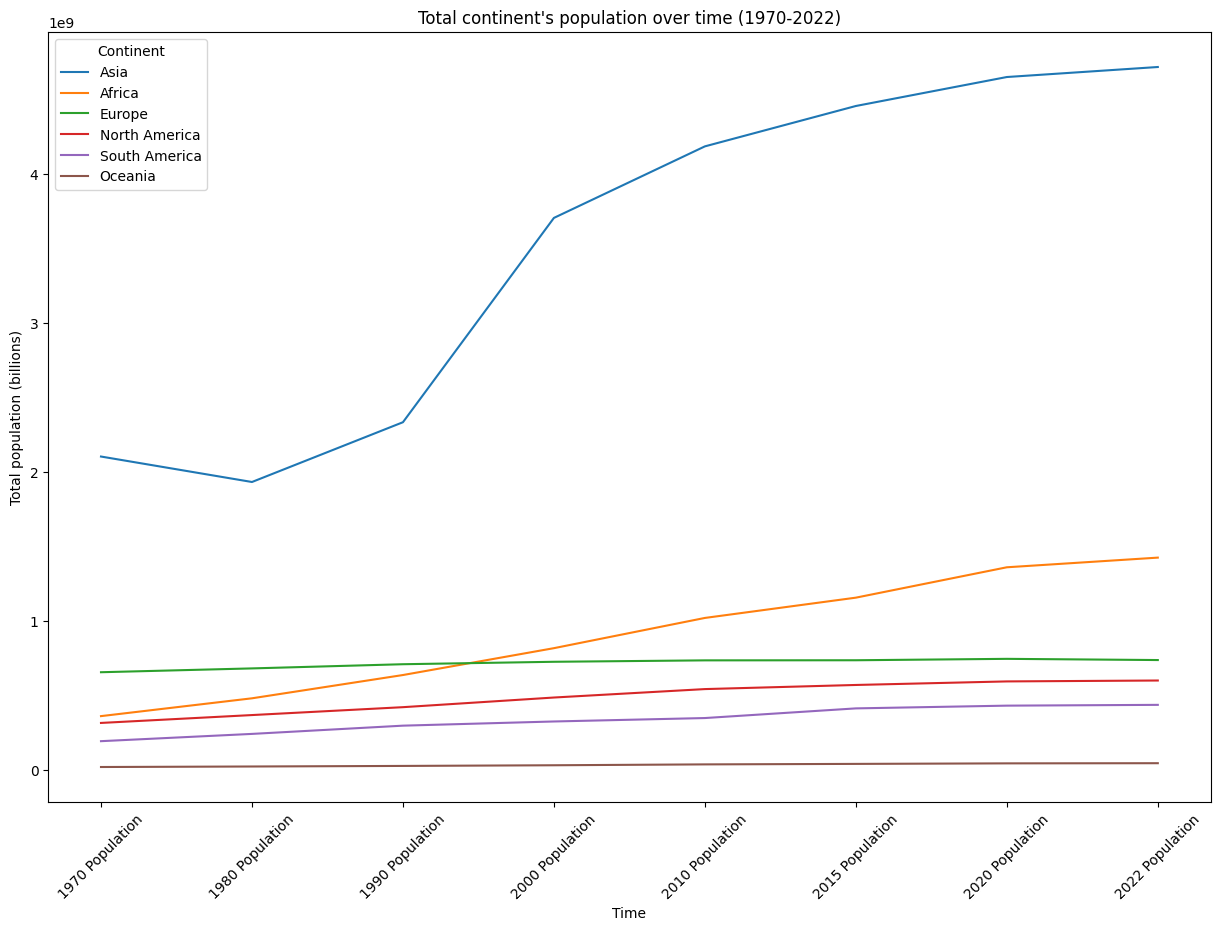

In [40]:
# finally plot to have more readable insights
df3.plot(xlabel="Time", ylabel="Total population (billions)", title="Total continent's population over time (1970-2022)", rot=45)

In 1970, Asia started with more than double the population of other continents, with Europe and Africa being the closest.

Since then, Asia's population has increased by a factor grater than 2x.

Europe has stayed roughly flat, while Africa has grown linearly, surpassing and doubling Europe's population.

## Outliers

A very important (crucial) aspect to inspect is the presence of **outliers**, i.e. values that are very far from the central part of the distribution of a feature.

How to define what an outlier is, is not so easy. Sometimes *weird/extreme* values are just part of the distribution. Other times, they may be the result of some typing errors in data collection, unspecified missing values encoding, ...

> The important thing is to be aware of outliers presence and consciously decide how to handle them!


A nice visualization that helps us spotting outliers is the [**Box plot**](https://en.wikipedia.org/wiki/Box_plot):

<Axes: >

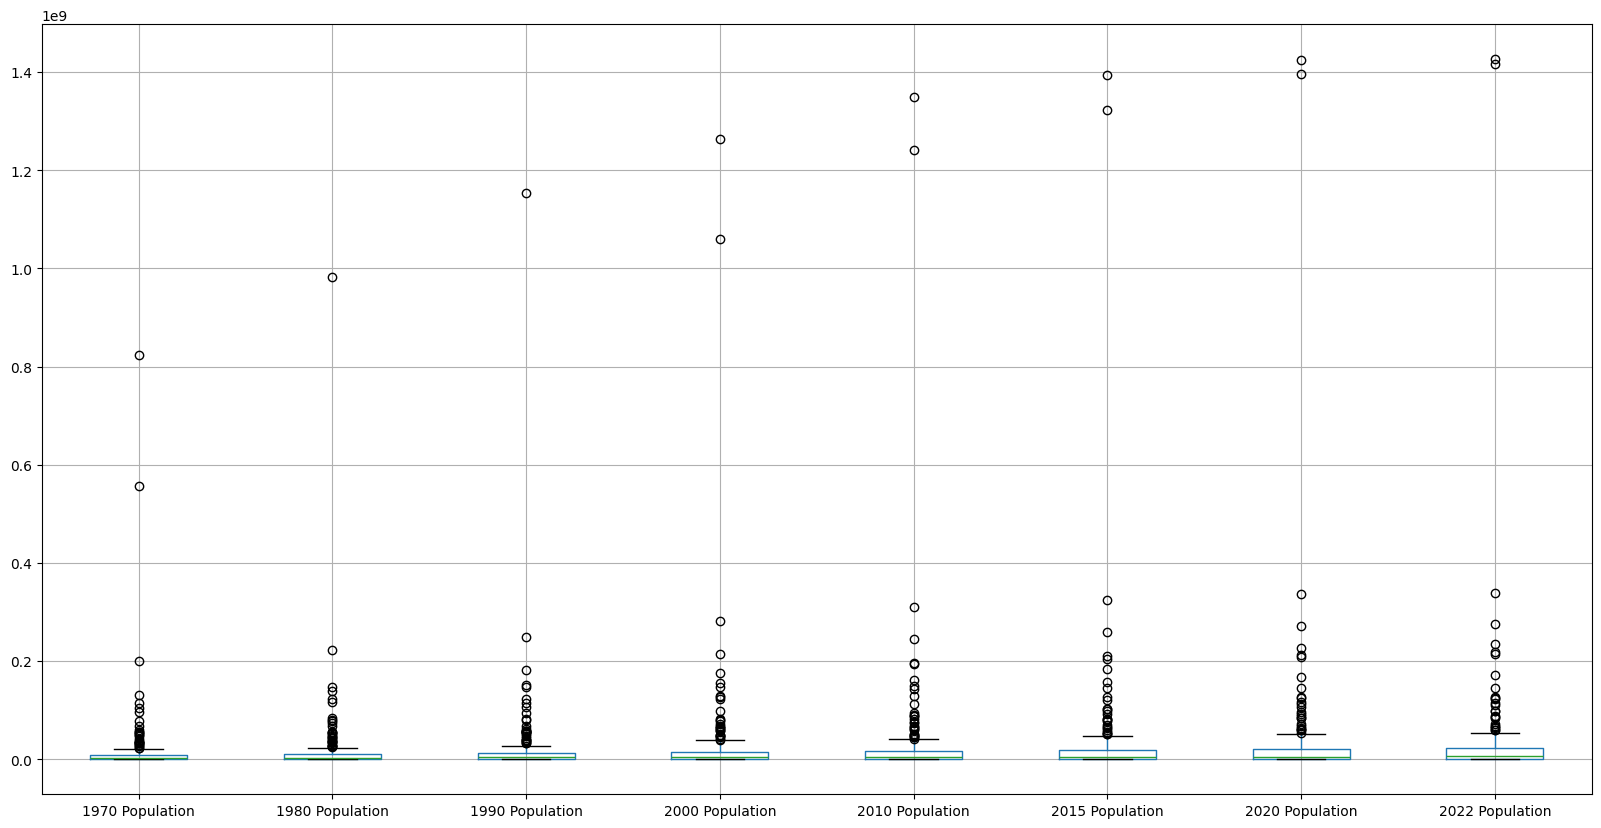

In [41]:
df[['1970 Population',
       '1980 Population', '1990 Population', '2000 Population',
       '2010 Population', '2015 Population', '2020 Population',
       '2022 Population']].boxplot(figsize=(20,10))

In [42]:
# bonus: notice you can subset dataframe's column by type
df.select_dtypes(include='float') # int, number, object

,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,41128771.00,38972230.00,33753499.00,28189672.00,19542982.00,10694796.00,12486631.00,10752971.00,652230.00,63.06,1.03,0.52
1,2842321.00,2866849.00,2882481.00,2913399.00,3182021.00,3295066.00,2941651.00,2324731.00,28748.00,98.87,1.00,0.04
2,44903225.00,43451666.00,39543154.00,35856344.00,30774621.00,25518074.00,18739378.00,13795915.00,2381741.00,18.85,1.02,0.56
3,44273.00,46189.00,51368.00,54849.00,58230.00,47818.00,32886.00,27075.00,199.00,222.48,0.98,0.00
4,79824.00,77700.00,71746.00,71519.00,66097.00,53569.00,35611.00,19860.00,468.00,170.56,1.01,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
229,11572.00,11655.00,12182.00,13142.00,14723.00,13454.00,11315.00,9377.00,142.00,81.49,1.00,0.00
230,575986.00,556048.00,491824.00,413296.00,270375.00,178529.00,116775.00,76371.00,266000.00,2.17,1.02,0.01
231,33696614.00,32284046.00,28516545.00,24743946.00,18628700.00,13375121.00,9204938.00,6843607.00,527968.00,63.82,1.02,0.42
232,20017675.00,18927715.00,NaN,13792086.00,9891136.00,7686401.00,5720438.00,4281671.00,752612.00,26.60,1.03,0.25


## Hands-on Exercise

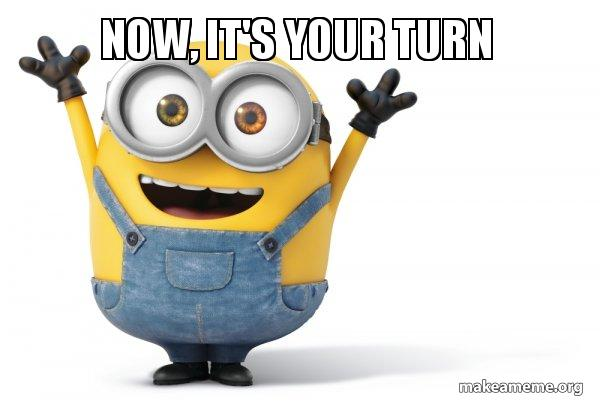

> Exercise: draw a **pie chart** for representing *median* country population by continent in 2022 (10 minutes)

<Axes: ylabel='2022 Population'>

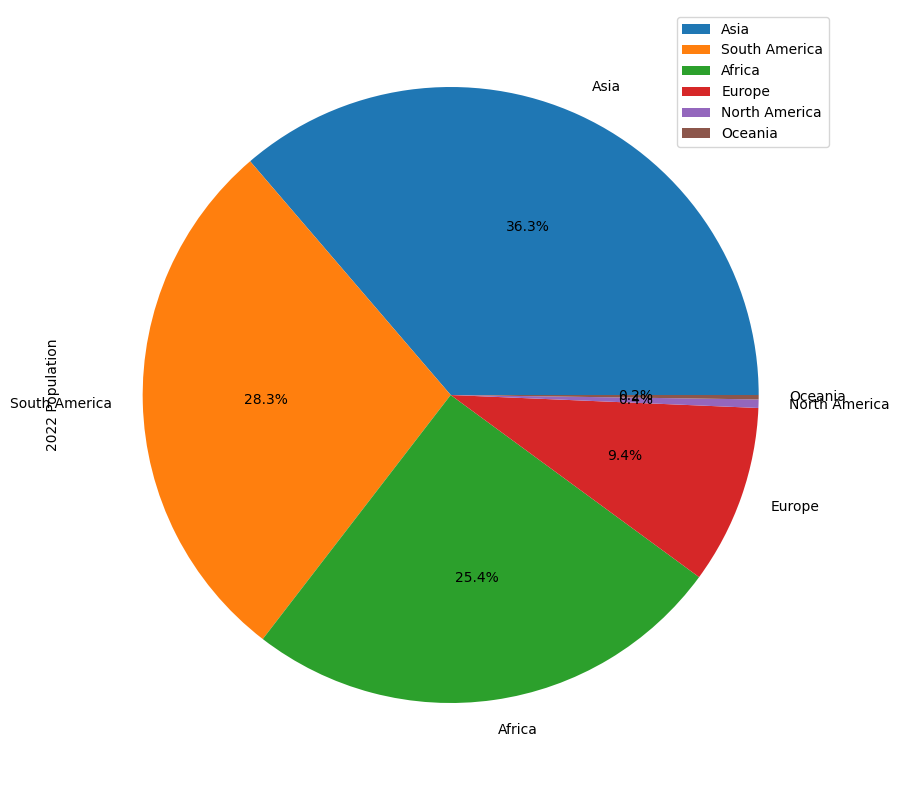

In [ ]:
#@title Solution

df_pie = df.groupby('Continent')[["2022 Population"]].median().sort_values(by="2022 Population", ascending=False)
df_pie.plot.pie(y="2022 Population", figsize=(10,10), autopct='%1.1f%%')

<Axes: ylabel='2022 Population'>

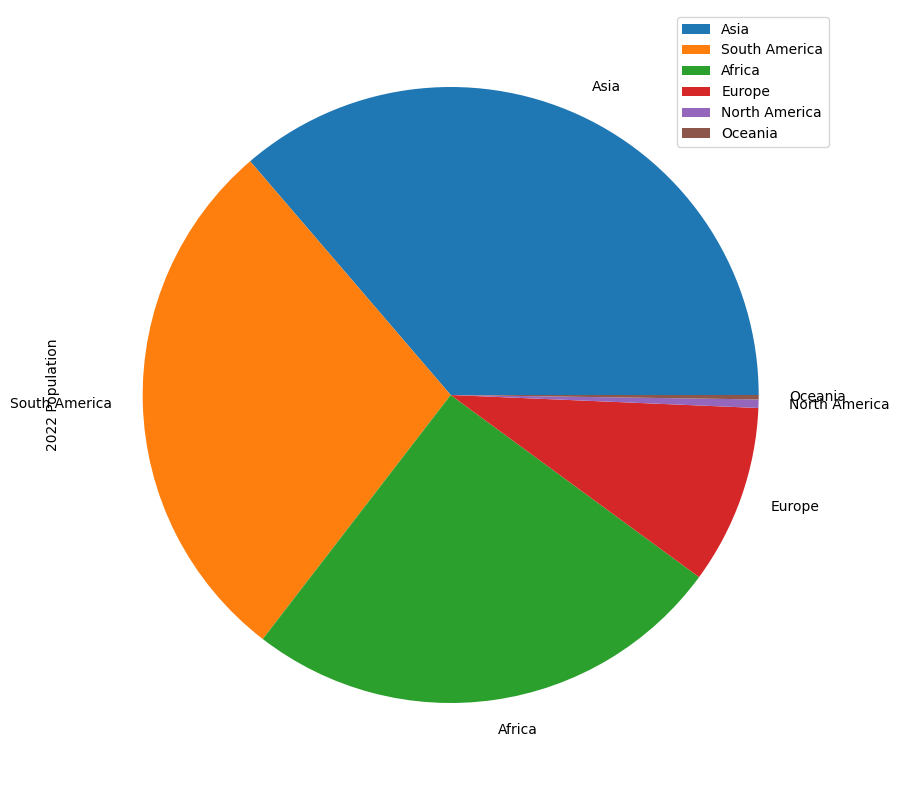

In [ ]:
df_pie_pct = df_pie / df_pie.sum()
df_pie_pct.plot.pie(y="2022 Population", figsize=(10,10)) # if you want to have percentage label use , autopct='%1.1f%%'